# Weather Explorer — temperature vs load and LMP

Exploration of zone-level weather from the `weather_zone_hourly` view (Open-Meteo; see README "Weather data") and a first look at
whether temperature carries signal for DA/RT price forecasting.

Three temperature series per zone:

| Column | What it is | Fair game for |
|---|---|---|
| `temp_obs_f` | ERA5 reanalysis — what actually happened | RT models, load analysis |
| `temp_fcst_d1_f` | GFS forecast issued ~24h before the hour | DA models, *with* leakage on late-day hours |
| `temp_fcst_d2_f` | GFS forecast issued ~48h before the hour | DA models — issued before the 10:30 EPT D-1 close for every hour |

All hour-of-day and calendar groupings below are in **Eastern local time (EPT)**, matching
PJM's operating day.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine

from config import DB, WEATHER_LOCATIONS

url = (f"postgresql+psycopg2://{DB['user']}:{DB['password']}"
       f"@{DB['host']}:{DB['port']}/{DB['dbname']}")
engine = create_engine(url)
conn = engine.connect()
print('Connected to', DB['dbname'])

ZONES_HERE = list(dict.fromkeys(loc['zone'] for loc in WEATHER_LOCATIONS))   # DOM, AEP, COMED, PECO

# Load areas don't share the LMP zone names: COMED = CE, PECO = PE, and AEP is
# split into four operating-company sub-areas that sum to the zone.
LOAD_AREAS = {
    'DOM':   ['DOM'],
    'AEP':   ['AEPAPT', 'AEPIMP', 'AEPKPT', 'AEPOPT'],
    'COMED': ['CE'],
    'PECO':  ['PE'],
}

# Fixed categorical order — color follows the zone, never its rank.
ZONE_COLOR = dict(zip(ZONES_HERE, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))
FCST_COLOR = {'d1': '#2a78d6', 'd2': '#eb6834'}
INK, INK_2, GRID = '#0b0b0b', '#52514e', '#e4e3df'

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': INK_2, 'axes.labelcolor': INK_2,
    'xtick.color': INK_2, 'ytick.color': INK_2,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.titlesize': 12, 'axes.titlecolor': INK, 'lines.linewidth': 2,
})

Connected to pjm_pipeline


## 1. Load everything into one hourly frame

One row per (zone, hour): weather, DA LMP, RT LMP, and metered load. Weather is the
spine (LEFT JOINs), so hours where RT or load hasn't landed yet show as `NaN`.

In [2]:
load_map_sql = ' UNION ALL '.join(
    f"SELECT '{a}' AS area, '{z}' AS zone" for z, areas in LOAD_AREAS.items() for a in areas)

df = pd.read_sql(f"""
    WITH load_zone AS (
        SELECT l.datetime_beginning_utc, m.zone, SUM(l.mw) AS load_mw
        FROM pjm_load_metered l
        JOIN ({load_map_sql}) m ON m.area = l.area
        GROUP BY 1, 2
    )
    SELECT w.datetime_beginning_utc AS ts, w.zone,
           w.temp_obs_f, w.temp_fcst_d1_f, w.temp_fcst_d2_f,
           da.lmp AS da_lmp, rt.lmp AS rt_lmp, lz.load_mw
    FROM weather_zone_hourly w
    LEFT JOIN pjm_da_lmp da ON da.datetime_beginning_utc = w.datetime_beginning_utc AND da.pnode_name = w.zone
    LEFT JOIN pjm_rt_lmp rt ON rt.datetime_beginning_utc = w.datetime_beginning_utc AND rt.pnode_name = w.zone
    LEFT JOIN load_zone  lz ON lz.datetime_beginning_utc = w.datetime_beginning_utc AND lz.zone = w.zone
    ORDER BY w.zone, w.datetime_beginning_utc
""", conn)

num_cols = ['temp_obs_f', 'temp_fcst_d1_f', 'temp_fcst_d2_f', 'da_lmp', 'rt_lmp', 'load_mw']
df[num_cols] = df[num_cols].astype(float)
df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('America/New_York')
df['date'] = df['ts'].dt.tz_localize(None).dt.normalize()
df['hour'] = df['ts'].dt.hour
df['month'] = df['ts'].dt.month
df['err_d1'] = df['temp_fcst_d1_f'] - df['temp_obs_f']    # + = forecast too warm
df['err_d2'] = df['temp_fcst_d2_f'] - df['temp_obs_f']
df['spread'] = df['da_lmp'] - df['rt_lmp']                 # + = DA priced above RT
print(f"{len(df):,} rows  {df.ts.min()} → {df.ts.max()}")
df.head()

167,232 rows  2021-12-31 19:00:00-05:00 → 2026-10-08 19:00:00-04:00


,ts,zone,temp_obs_f,temp_fcst_d1_f,temp_fcst_d2_f,da_lmp,rt_lmp,load_mw,date,hour,month,err_d1,err_d2,spread
0,2021-12-31 19:00:00-05:00,AEP,50.7,50.3,51.6,NaN,NaN,NaN,2021-12-31,19,12,-0.4,0.9,NaN
1,2021-12-31 20:00:00-05:00,AEP,51.1,51.1,51.7,NaN,NaN,NaN,2021-12-31,20,12,0.0,0.6,NaN
2,2021-12-31 21:00:00-05:00,AEP,52.3,51.3,51.1,NaN,NaN,NaN,2021-12-31,21,12,-1.0,-1.2,NaN
3,2021-12-31 22:00:00-05:00,AEP,53.7,52.3,51.5,NaN,NaN,NaN,2021-12-31,22,12,-1.4,-2.2,NaN
4,2021-12-31 23:00:00-05:00,AEP,56.1,52.6,52.8,NaN,NaN,NaN,2021-12-31,23,12,-3.5,-3.3,NaN


## 2. Coverage

In [3]:
coverage = df.groupby('zone')[num_cols].count().T
coverage.insert(0, 'expected', df.groupby('zone').size().iloc[0])
coverage

zone,expected,AEP,COMED,DOM,PECO
temp_obs_f,41808,41808,41808,41808,41808
temp_fcst_d1_f,41808,41316,41316,41316,41316
temp_fcst_d2_f,41808,41292,41292,41292,41292
da_lmp,41808,41735,41735,41735,41735
rt_lmp,41808,41711,41711,41711,41711
load_mw,41808,41519,41519,41519,41519


Weather columns are complete except the known GFS archive gap (2023-12-29 → 2024-01-20).
DA/RT/load trail at the end because PJM publishes on a lag. The weather data also has the
25th hour on DST fall-back days, which the PJM tables don't (see `03_lmp_data_validation`).

In [4]:
gap = df[df.zone == 'DOM'].loc[lambda d: d.temp_fcst_d2_f.isna(), 'date']
print('Forecast-null days (DOM):', gap.min().date(), '→', gap.max().date(), f'({gap.nunique()} days)')

Forecast-null days (DOM): 2023-12-29 → 2024-01-20 (23 days)


### 2.1 Data check: wind, humidity, cloud cover, WWP and THI

These columns were added after the temperature series (see README "Weather data"). The checks:

1. **Coverage.** Observed values should be complete from 2022. Forecasts should start on 2024-01-20, when Open-Meteo began archiving these GFS variables, with no gaps after that.
2. **Physical ranges.** Wind ≥ 0, humidity and cloud cover within 0–100%. GFS occasionally returns −1% or 101% cloud cover (an interpolation artifact), so `ingest_weather.py` clamps percentages to 0–100. This check confirms the clamp is working.
3. **Formulas.** Recompute WWP and THI from the stored inputs using PJM Manual 19 §3.2, and confirm they match the generated columns. Also confirm each index is null exactly when one of its inputs is.
4. **Forecast skill.** The 48h forecast (d2) should usually be a bit worse than the 24h one (d1), as with temperature in §4. This is a sanity check, not a hard pass/fail. See the note after the table for the one consistent exception.

**Zone weighting.** Each zone's weather is the weighted average of its locations
(`weather_locations`, synced from `config.WEATHER_LOCATIONS`). DOM blends Dulles (60%),
Richmond (20%) and Norfolk (20%); the other zones have one station each. WWP and THI are
recomputed from the weighted inputs, not averaged from each station's index. The first cell
below recomputes the weighted averages from the raw per-location rows and checks they match
the view.

In [5]:
locs = pd.read_sql("SELECT location, zone, weight FROM weather_locations", conn)
display(locs.sort_values(['zone', 'weight'], ascending=[True, False]).set_index('location'))

BASE_COLS = [f'{v}_{s}_{u}' for v, u in [('temp', 'f'), ('wind', 'mph'), ('rh', 'pct'), ('cloud', 'pct')]
             for s in ['obs', 'fcst_d1', 'fcst_d2']]
raw = pd.read_sql(f"SELECT datetime_beginning_utc AS ts, location, {', '.join(BASE_COLS)} FROM weather_hourly", conn)
raw[BASE_COLS] = raw[BASE_COLS].astype(float)
raw = raw.merge(locs, on='location')

def weighted(g):
    # NULL unless every location in the zone has the value — same rule as the view
    n_zone = (locs.zone == g.zone.iloc[0]).sum()
    return pd.Series({c: (g[c] * g.weight).sum() / g.weight.sum()
                      if g[c].notna().sum() == n_zone else np.nan for c in BASE_COLS})

dom_raw = raw[raw.zone == 'DOM']
expected = dom_raw.groupby('ts').apply(weighted, include_groups=False)
view = pd.read_sql(f"SELECT datetime_beginning_utc AS ts, {', '.join(BASE_COLS)} FROM weather_zone_hourly WHERE zone = 'DOM'",
                   conn).set_index('ts').astype(float)
cmp = expected.join(view, rsuffix='_view')
weight_check = pd.DataFrame({
    'max_abs_diff': [np.nanmax(np.abs(cmp[c] - cmp[c + '_view'])) for c in BASE_COLS],
    'null_mismatch': [int((cmp[c].isna() != cmp[c + '_view'].isna()).sum()) for c in BASE_COLS],
}, index=BASE_COLS)
ok = (weight_check.max_abs_diff <= 0.05 + 1e-9).all() and (weight_check.null_mismatch == 0).all()
print('PASS' if ok else 'FAIL', '— DOM view equals 60/20/20 weighted average of IAD/RIC/ORF')
weight_check.style.format({'max_abs_diff': '{:.3f}'})

,zone,weight
location,,
CMH,AEP,1.0
ORD,COMED,1.0
IAD,DOM,0.6
RIC,DOM,0.2
ORF,DOM,0.2
PHL,PECO,1.0


PASS — DOM view equals 60/20/20 weighted average of IAD/RIC/ORF


,max_abs_diff,null_mismatch
temp_obs_f,0.040,0
temp_fcst_d1_f,0.040,0
temp_fcst_d2_f,0.040,0
wind_obs_mph,0.040,0
wind_fcst_d1_mph,0.040,0
wind_fcst_d2_mph,0.040,0
rh_obs_pct,0.000,0
rh_fcst_d1_pct,0.000,0
rh_fcst_d2_pct,0.000,0
cloud_obs_pct,0.000,0


In [6]:
# How different are the three DOM stations? Large differences mean the weighting matters.
station_summary = (dom_raw.groupby('location')[['temp_obs_f', 'wind_obs_mph', 'rh_obs_pct']]
                          .mean().round(1).loc[['IAD', 'RIC', 'ORF']])
station_summary.columns = ['mean temp (°F)', 'mean wind (mph)', 'mean RH (%)']
station_summary

,mean temp (°F),mean wind (mph),mean RH (%)
location,,,
IAD,57.6,6.4,67.3
RIC,60.1,6.5,69.5
ORF,62.0,9.7,71.6


In [7]:
VARS = {'temp': 'f', 'wind': 'mph', 'rh': 'pct', 'cloud': 'pct', 'wwp': 'f', 'thi': 'f'}
SOURCES = ['obs', 'fcst_d1', 'fcst_d2']
WX_COLS = [f'{v}_{s}_{u}' for v, u in VARS.items() for s in SOURCES]

wx = pd.read_sql(f"SELECT datetime_beginning_utc AS ts, zone, {', '.join(WX_COLS)} FROM weather_zone_hourly", conn)
wx[WX_COLS] = wx[WX_COLS].astype(float)
wx['ts'] = pd.to_datetime(wx['ts'], utc=True)

rows = []
for col in WX_COLS:
    s = wx.set_index('ts')[col].dropna()
    first, last = s.index.min(), s.index.max()
    # nulls *within* the column's own first→last span, per location (4 locations)
    span_hours = int((last - first) / pd.Timedelta(hours=1)) + 1
    rows.append({'column': col, 'first': first.strftime('%Y-%m-%d %H:%M'),
                 'last': last.strftime('%Y-%m-%d %H:%M'), 'rows': len(s),
                 'gaps_in_span': span_hours * len(ZONES_HERE) - len(s)})
pd.DataFrame(rows).set_index('column')

,first,last,rows,gaps_in_span
column,,,,
temp_obs_f,2022-01-01 00:00,2026-10-08 23:00,167232,0
temp_fcst_d1_f,2022-01-01 00:00,2026-10-08 23:00,165264,1968
temp_fcst_d2_f,2022-01-01 00:00,2026-10-08 23:00,165168,2064
wind_obs_mph,2022-01-01 00:00,2026-10-08 23:00,167232,0
wind_fcst_d1_mph,2024-01-19 12:00,2026-10-08 23:00,95376,0
wind_fcst_d2_mph,2024-01-20 12:00,2026-10-08 23:00,95280,0
rh_obs_pct,2022-01-01 00:00,2026-10-08 23:00,167232,0
rh_fcst_d1_pct,2024-01-19 12:00,2026-10-08 23:00,95376,0
rh_fcst_d2_pct,2024-01-20 12:00,2026-10-08 23:00,95280,0


`gaps_in_span` counts missing hours between each column's first and last value. Expect
0 for every observed column and for the new forecast columns. The temperature-forecast
columns show the known 2023-12-29 → 2024-01-20 gap (§2).

In [8]:
RANGES = {'wind': (0, 100), 'rh': (0, 100), 'cloud': (0, 100)}
checks = []
for v, (lo, hi) in RANGES.items():
    for src in SOURCES:
        col = f'{v}_{src}_{VARS[v]}'
        x = wx[col].dropna()
        checks.append({'column': col, 'min': x.min(), 'max': x.max(),
                       'out_of_range': int(((x < lo) | (x > hi)).sum())})
ranges = pd.DataFrame(checks).set_index('column')
print('PASS' if ranges.out_of_range.sum() == 0 else 'FAIL', '— physical range check')
ranges

PASS — physical range check


,min,max,out_of_range
column,,,
wind_obs_mph,0.0,29.6,0
wind_fcst_d1_mph,0.0,31.8,0
wind_fcst_d2_mph,0.0,28.2,0
rh_obs_pct,12.0,100.0,0
rh_fcst_d1_pct,13.0,100.0,0
rh_fcst_d2_pct,13.0,100.0,0
cloud_obs_pct,0.0,100.0,0
cloud_fcst_d1_pct,0.0,100.0,0
cloud_fcst_d2_pct,0.0,100.0,0


In [9]:
def wwp(t, w):
    return np.where(w > 10, t - 0.5 * (w - 10), t)

def thi(t, h):
    return np.where(t >= 58, t - 0.55 * (1 - h / 100) * (t - 58), t)

TOL = 0.05 + 1e-9   # stored at one decimal place
formula = []
for src in SOURCES:
    t, w, h = wx[f'temp_{src}_f'], wx[f'wind_{src}_mph'], wx[f'rh_{src}_pct']
    for name, expected, inputs_ok in [('wwp', wwp(t, w), t.notna() & w.notna()),
                                      ('thi', thi(t, h), t.notna() & h.notna())]:
        stored = wx[f'{name}_{src}_f']
        formula.append({
            'column': f'{name}_{src}_f',
            'max_abs_diff': np.nanmax(np.abs(expected - stored)),
            'null_mismatch': int((stored.notna() != inputs_ok).sum()),
            'hours_adjusted': int((stored.round(1) != t.round(1)).sum()),
        })
formula = pd.DataFrame(formula).set_index('column')
ok = (formula.max_abs_diff <= TOL).all() and (formula.null_mismatch == 0).all()
print('PASS' if ok else 'FAIL', '— WWP/THI match Manual 19 formulas, nulls consistent with inputs')
formula.style.format({'max_abs_diff': '{:.3f}'})

PASS — WWP/THI match Manual 19 formulas, nulls consistent with inputs


,max_abs_diff,null_mismatch,hours_adjusted
column,,,
wwp_obs_f,0.050,0,31165
thi_obs_f,0.050,0,80447
wwp_fcst_d1_f,0.050,0,93030
thi_fcst_d1_f,0.050,0,120427
wwp_fcst_d2_f,0.050,0,92636
thi_fcst_d2_f,0.050,0,120888


`hours_adjusted` is how often the index differs from plain temperature. For WWP that means
wind above 10 mph; for THI, 58°F or warmer with humidity below 100%. If these counts were
near zero, the indices would add nothing over temperature.

In [10]:
recent = wx[wx.ts >= '2024-01-21']
skill_rows = []
for zone in ZONES_HERE:
    z = recent[recent.zone == zone]
    for v, u in VARS.items():
        obs = z[f'{v}_obs_{u}']
        r = {'zone': zone, 'variable': v}
        for lead in ['d1', 'd2']:
            r[f'mae_{lead}'] = (z[f'{v}_fcst_{lead}_{u}'] - obs).abs().mean()
        skill_rows.append(r)
wx_skill = pd.DataFrame(skill_rows).set_index(['zone', 'variable'])
wx_skill['d2_worse'] = wx_skill.mae_d2 >= wx_skill.mae_d1
print('Forecast MAE vs observed, 2024-01-21 onward (units: °F, mph, or % points)')
print(f"d2 at least as bad as d1 in {wx_skill.d2_worse.sum()}/{len(wx_skill)} cases")
wx_skill.style.format({'mae_d1': '{:.2f}', 'mae_d2': '{:.2f}'})

Forecast MAE vs observed, 2024-01-21 onward (units: °F, mph, or % points)
d2 at least as bad as d1 in 19/24 cases


**Wind is the exception:** d2 has a *lower* MAE than d1 in every zone. That isn't a data
error. The d1 wind forecast varies more than the observed series (its standard deviation runs
roughly 0.3–0.6 mph higher, depending on zone), while correlating with it about as well as d2 does. ERA5 is a
smooth, coarse (~30 km) reanalysis, so a sharper but noisier forecast is penalized on MAE
against it. A likely cause is Open-Meteo's `gfs_seamless` blending in the higher-resolution
HRRR model at shorter lead times (not confirmed). For modelling it doesn't matter much,
because wind enters only through WWP, and WWP's d1 < d2 ordering holds in every zone.

AEP humidity is the one other exception: d2 beats d1 there by about a percentage point, but
not in the other zones. It doesn't carry through to THI, whose d1 < d2 ordering holds everywhere.

Finally, a look at what the indices do in the weather they were designed for: the late-January 2026 cold snap (WWP) and the early-July 2026 heat (THI), at DOM.

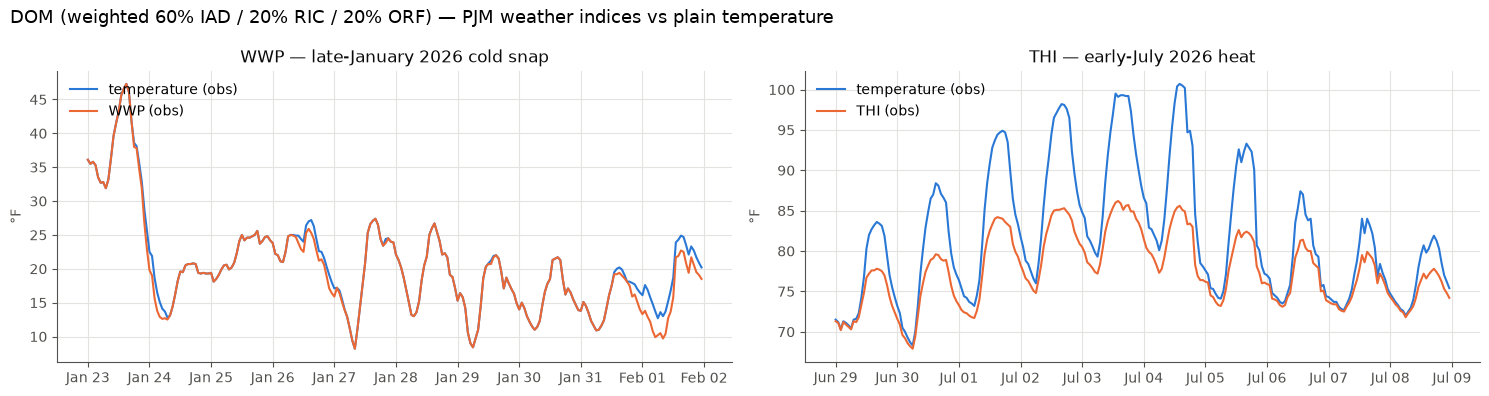

In [11]:
dom = wx[wx.zone == 'DOM'].set_index('ts').sort_index().tz_convert('America/New_York')
windows = [('2026-01-23', '2026-02-01', 'wwp', 'WWP — late-January 2026 cold snap'),
           ('2026-06-29', '2026-07-08', 'thi', 'THI — early-July 2026 heat')]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, (start, end, idx, title) in zip(axes, windows):
    w = dom.loc[start:end]
    ax.plot(w.index, w['temp_obs_f'], color='#2a78d6', linewidth=1.5, label='temperature (obs)')
    ax.plot(w.index, w[f'{idx}_obs_f'], color='#eb6834', linewidth=1.5, label=f'{idx.upper()} (obs)')
    ax.set_title(title)
    ax.set_ylabel('°F')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.legend(frameon=False, loc='upper left')
fig.suptitle('DOM (weighted 60% IAD / 20% RIC / 20% ORF) — PJM weather indices vs plain temperature', x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Temperature history by zone

Daily mean observed temperature, 7-day rolling. The four zones move together, which is
expected for one weather pattern across the mid-Atlantic and Midwest. The useful
differences are in the extremes: Chicago runs colder in winter, and DOM and PECO run hotter in summer.

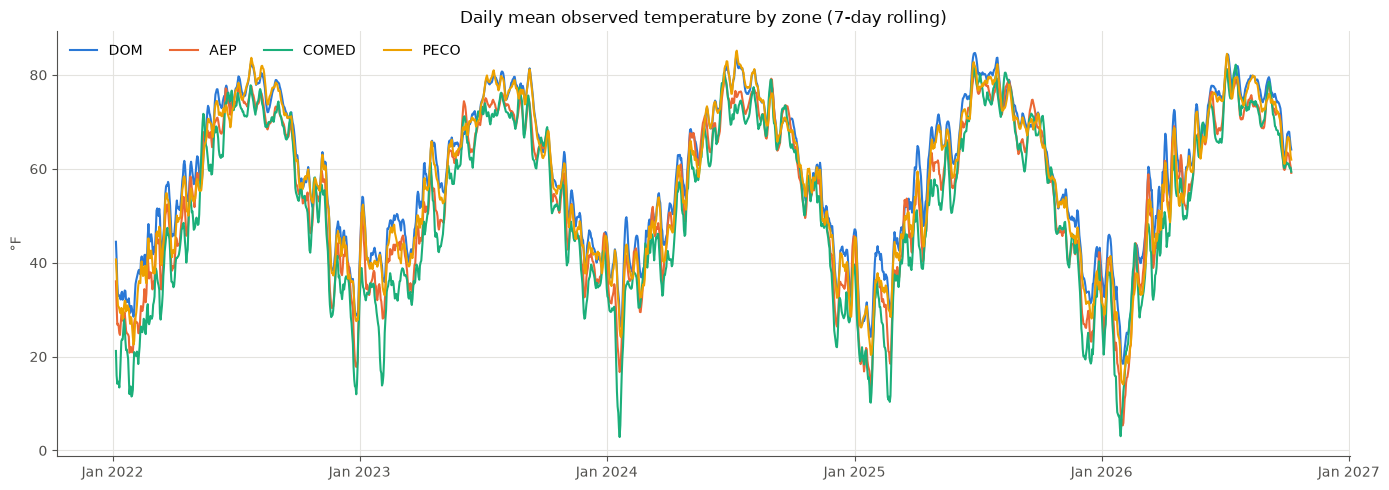

In [12]:
daily = (df.groupby(['zone', 'date'])
           .agg(temp=('temp_obs_f', 'mean'), da=('da_lmp', 'mean'), rt=('rt_lmp', 'mean'),
                load=('load_mw', 'mean'))
           .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))
for zone in ZONES_HERE:
    s = daily[daily.zone == zone].set_index('date')['temp'].rolling(7).mean()
    ax.plot(s.index, s, color=ZONE_COLOR[zone], label=zone, linewidth=1.5)
ax.set_title('Daily mean observed temperature by zone (7-day rolling)')
ax.set_ylabel('°F')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(ncol=4, frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

## 4. Forecast skill: d1 vs d2

Error = forecast − observed. MAE says how wrong the forecast is. Bias says whether it
leans warm (+) or cold (−). d2 is a day older, so it should be somewhat worse. The
question is how much skill we give up by using the leakage-free series.

In [13]:
skill = df.groupby('zone').agg(
    mae_d1=('err_d1', lambda e: e.abs().mean()),
    mae_d2=('err_d2', lambda e: e.abs().mean()),
    bias_d1=('err_d1', 'mean'),
    bias_d2=('err_d2', 'mean'),
    p95_abs_err_d2=('err_d2', lambda e: e.abs().quantile(0.95)),
).loc[ZONES_HERE]
skill.style.format('{:.2f} °F')

,mae_d1,mae_d2,bias_d1,bias_d2,p95_abs_err_d2
zone,,,,,
DOM,1.90 °F,2.22 °F,-0.10 °F,-0.33 °F,5.80 °F
AEP,2.41 °F,2.60 °F,0.23 °F,-0.30 °F,6.90 °F
COMED,2.72 °F,3.24 °F,1.00 °F,1.73 °F,8.30 °F
PECO,2.32 °F,2.73 °F,0.24 °F,0.92 °F,7.20 °F


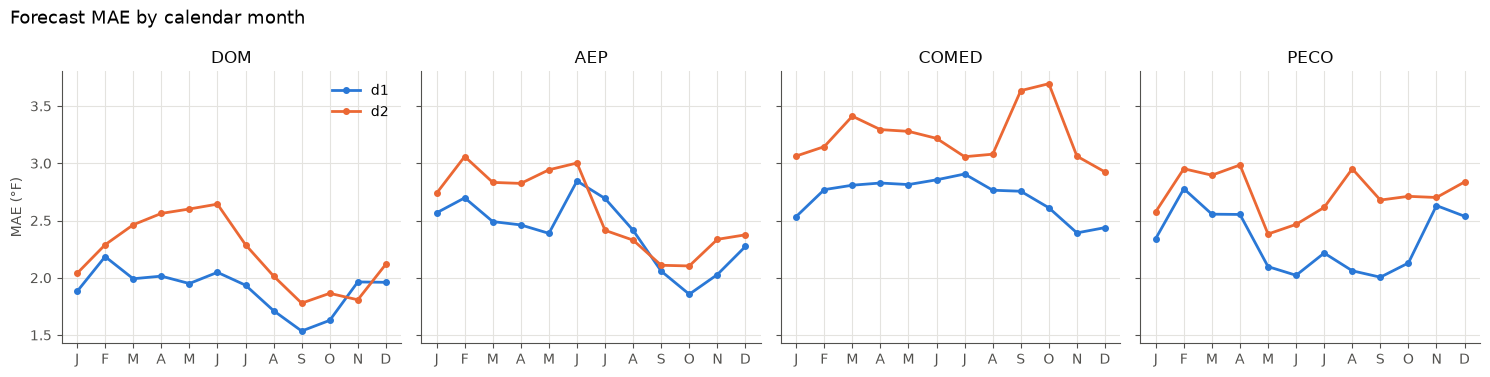

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, zone in zip(axes, ZONES_HERE):
    z = df[df.zone == zone]
    for lead in ['d1', 'd2']:
        m = z.groupby('month')[f'err_{lead}'].apply(lambda e: e.abs().mean())
        ax.plot(m.index, m.values, color=FCST_COLOR[lead], marker='o', markersize=4, label=lead)
    ax.set_title(zone)
    ax.set_xticks(range(1, 13), list('JFMAMJJASOND'))
axes[0].set_ylabel('MAE (°F)')
axes[0].legend(frameon=False)
fig.suptitle('Forecast MAE by calendar month', x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

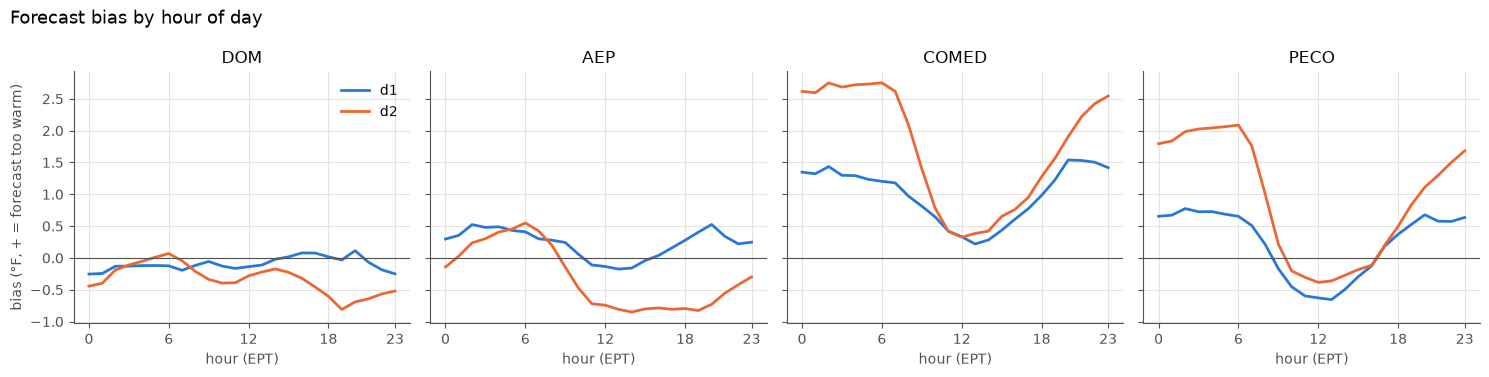

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, zone in zip(axes, ZONES_HERE):
    z = df[df.zone == zone]
    for lead in ['d1', 'd2']:
        b = z.groupby('hour')[f'err_{lead}'].mean()
        ax.plot(b.index, b.values, color=FCST_COLOR[lead], label=lead)
    ax.axhline(0, color=INK_2, linewidth=0.8)
    ax.set_title(zone)
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xlabel('hour (EPT)')
axes[0].set_ylabel('bias (°F, + = forecast too warm)')
axes[0].legend(frameon=False)
fig.suptitle('Forecast bias by hour of day', x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

A consistent hour-of-day bias is a systematic error a model can learn to correct, either
by including `hour` as a feature or by bias-correcting the forecast before using it.

## 5. Temperature vs load

The classic weather-load curve: load rises in both directions from a comfortable ~60°F,
heating on the left and cooling on the right. Hexbin, because 40k hourly points overplot as a scatter.

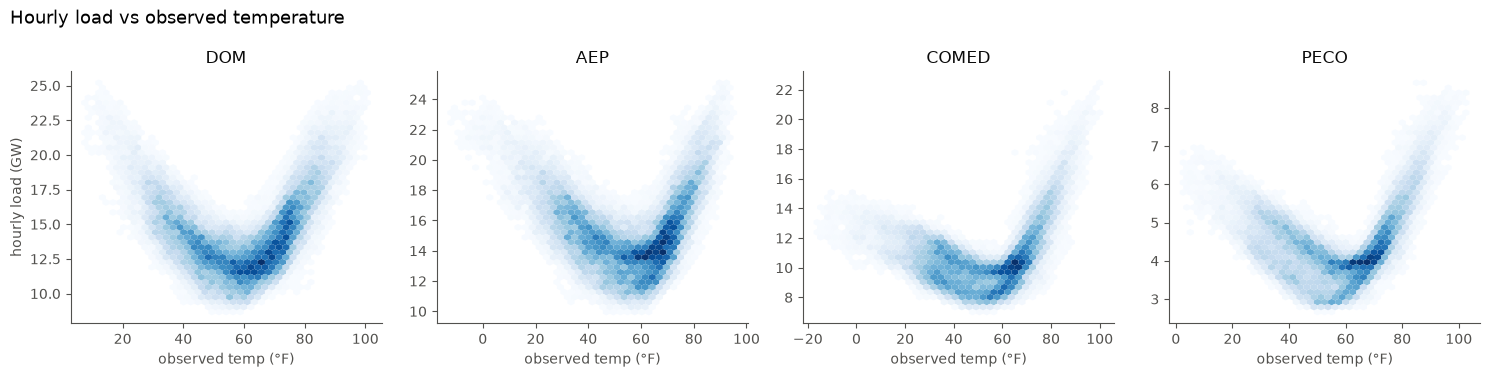

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, zone in zip(axes, ZONES_HERE):
    z = df[(df.zone == zone)].dropna(subset=['temp_obs_f', 'load_mw'])
    ax.hexbin(z.temp_obs_f, z.load_mw / 1000, gridsize=40, cmap='Blues', mincnt=1, linewidths=0)
    ax.set_title(zone)
    ax.set_xlabel('observed temp (°F)')
    ax.grid(False)
axes[0].set_ylabel('hourly load (GW)')
fig.suptitle('Hourly load vs observed temperature', x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Temperature vs price

Hourly DA LMP binned by temperature: the median, plus a 25–75% band, because price spikes
make the mean unreliable. Both price tails should sit at the temperature extremes, but
price is far noisier than load. Gas prices, outages, and congestion all move LMP at any
temperature, so expect the curve to be weaker than §5.

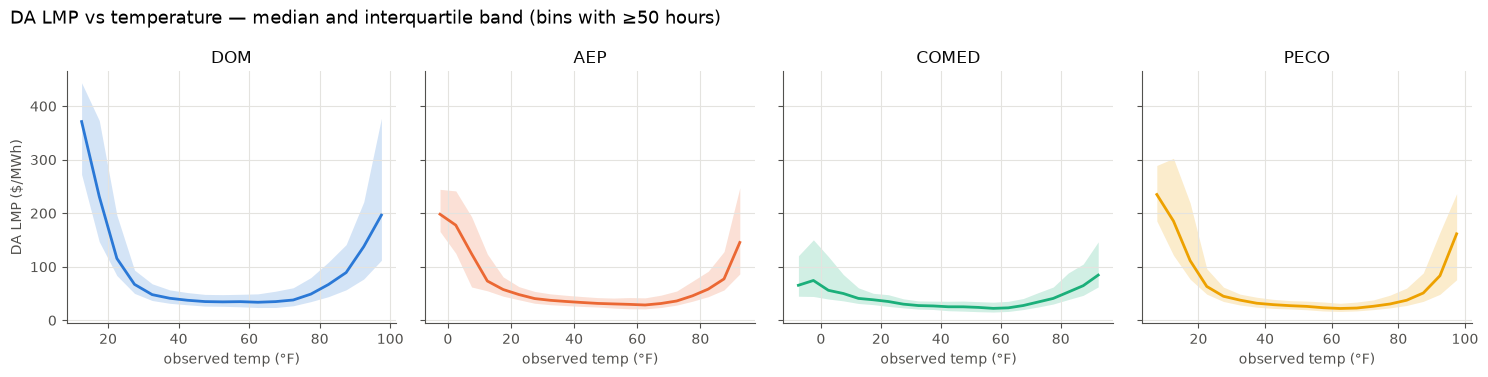

In [17]:
bins = np.arange(-15, 111, 5)
df['temp_bin'] = pd.cut(df['temp_obs_f'], bins, labels=bins[:-1] + 2.5).astype(float)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, zone in zip(axes, ZONES_HERE):
    g = df[df.zone == zone].groupby('temp_bin')['da_lmp']
    q = g.quantile([0.25, 0.5, 0.75]).unstack()
    q = q[g.size() >= 50]                      # drop sparse extreme bins
    ax.fill_between(q.index, q[0.25], q[0.75], color=ZONE_COLOR[zone], alpha=0.2, linewidth=0)
    ax.plot(q.index, q[0.5], color=ZONE_COLOR[zone])
    ax.set_title(zone)
    ax.set_xlabel('observed temp (°F)')
axes[0].set_ylabel('DA LMP ($/MWh)')
fig.suptitle('DA LMP vs temperature — median and interquartile band (bins with ≥50 hours)',
             x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

Price levels shifted a lot across 2022–2026 (the 2022 gas spike, then higher capacity and
datacenter-driven demand), so pooling every year blurs this curve. The same view split by
year, for DOM:

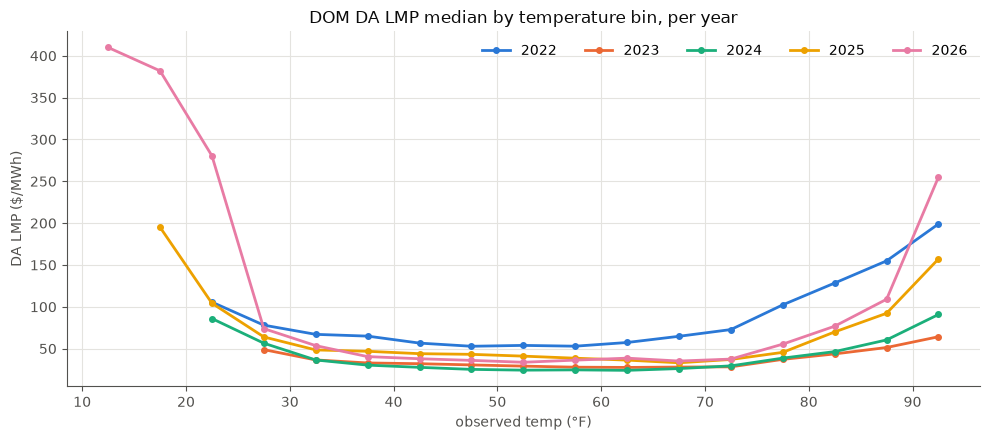

In [18]:
zone = 'DOM'
z = df[df.zone == zone].assign(year=df.ts.dt.year).query('year >= 2022')   # first UTC hours land on 2021-12-31 EPT
years = sorted(z.year.unique())
year_color = dict(zip(years, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))

fig, ax = plt.subplots(figsize=(10, 4.5))
for y in years:
    g = z[z.year == y].groupby('temp_bin')['da_lmp']
    med = g.median()[g.size() >= 50]
    ax.plot(med.index, med.values, color=year_color[y], label=str(y), marker='o', markersize=4)
ax.set_title(f'{zone} DA LMP median by temperature bin, per year')
ax.set_xlabel('observed temp (°F)')
ax.set_ylabel('DA LMP ($/MWh)')
ax.legend(frameon=False, ncol=len(years))
plt.tight_layout()
plt.show()

## 7. Feature check: does temperature help forecast prices?

§6 shows the price response is a **hockey stick, not a U**. It's nearly flat from 30°F to
90°F, takes off below about 25°F (winter gas tightness), and rises only mildly in heat.
Most of each hour's price variance comes from the time of day and the prevailing price
level, so a correlation over all hours (e.g. Spearman of `|T − 65|` against LMP) comes
out around 0.1. That number hides the real effect.

The fairer test is out of sample. Fit a simple model on log price, then check whether
temperature improves it on data it hasn't seen:

- **Baseline:** hour-of-day × weekend dummies, plus the trailing 14-day mean log price
  lagged 48h, so it's known before the DA close.
- **+ temperature:** baseline plus a piecewise-linear spline in temperature (knots at
  20/35/50/65/75/85°F), which can bend into the hockey stick.

Train on data before 2025-07-01, test from 2025-07-01 onward. Run the "+ temperature" model
three times, once per temperature source. `obs` is the leaky upper bound; `d1`/`d2` are
what the market could actually have seen.

In [19]:
KNOTS = [20, 35, 50, 65, 75, 85]
SPLIT = pd.Timestamp('2025-07-01', tz='America/New_York')
TEMP_SRC = {'obs': 'temp_obs_f', 'd1': 'temp_fcst_d1_f', 'd2': 'temp_fcst_d2_f'}

def hinge(t):
    return np.column_stack([t] + [np.maximum(t - k, 0) for k in KNOTS])

rows = []
for zone in ZONES_HERE:
    z = df[df.zone == zone].sort_values('ts')
    hour_dummies = pd.get_dummies(z.hour.astype(str) + '_' + (z.ts.dt.dayofweek >= 5).astype(str),
                                  drop_first=True).astype(float).values
    for target in ['da_lmp', 'rt_lmp']:
        y = np.log(z[target].clip(lower=1)).values
        level = pd.Series(y).shift(48).rolling(24 * 14, min_periods=24 * 7).mean().values
        base = np.column_stack([np.ones(len(z)), level, hour_dummies])
        # same rows for every variant: drop anything missing in any temperature source
        ok = ~(np.isnan(base).any(axis=1) | np.isnan(y) | z[list(TEMP_SRC.values())].isna().any(axis=1).values)
        train, test = ok & (z.ts < SPLIT).values, ok & (z.ts >= SPLIT).values

        r = {'zone': zone, 'target': target.split('_')[0].upper()}
        for name, X in [('baseline', base)] + [(src, np.column_stack([base, hinge(z[col].values)]))
                                               for src, col in TEMP_SRC.items()]:
            beta = np.linalg.lstsq(X[train], y[train], rcond=None)[0]
            resid = y[test] - X[test] @ beta
            r[name] = 1 - (resid ** 2).sum() / ((y[test] - y[test].mean()) ** 2).sum()
        rows.append(r)

r2 = pd.DataFrame(rows).set_index(['zone', 'target'])
r2['gain_d2'] = r2['d2'] - r2['baseline']
r2.style.format('{:.3f}').set_caption('Out-of-sample R² on log price (test: 2025-07-01 → present)')

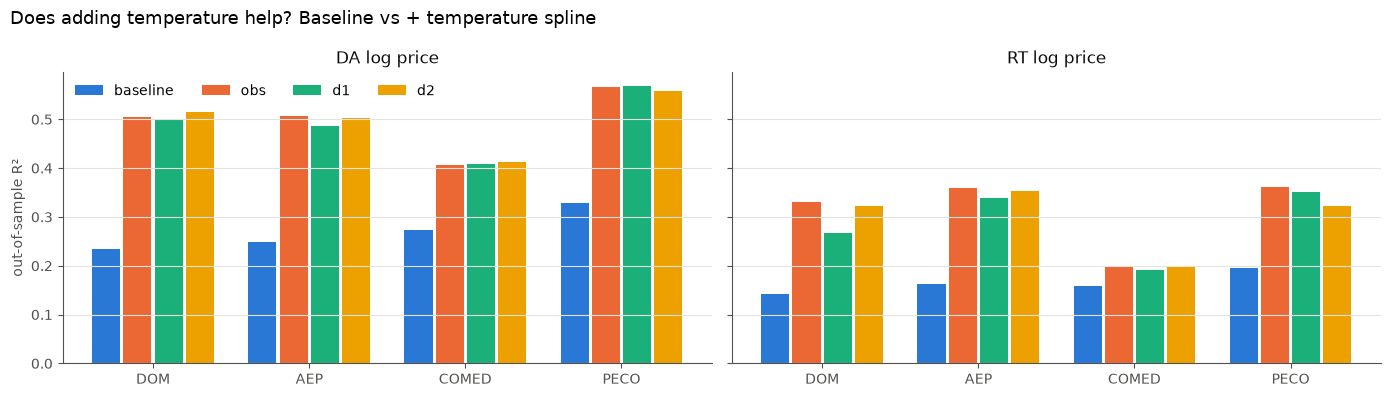

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
x = np.arange(len(ZONES_HERE))
w = 0.2
variants = [('baseline', '#2a78d6'), ('obs', '#eb6834'), ('d1', '#1baf7a'), ('d2', '#eda100')]
for ax, target in zip(axes, ['DA', 'RT']):
    sub = r2.xs(target, level='target').loc[ZONES_HERE]
    for i, (v, color) in enumerate(variants):
        ax.bar(x + (i - 1.5) * w, sub[v], width=w - 0.02, color=color, label=v)
    ax.set_xticks(x, ZONES_HERE)
    ax.set_title(f'{target} log price')
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('out-of-sample R²')
axes[0].legend(frameon=False, ncol=4, loc='upper left')
fig.suptitle('Does adding temperature help? Baseline vs + temperature spline', x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

Read the chart for two things:

1. **The gap between baseline and the temperature bars.** That's what weather is worth
   on top of time-of-day and the recent price level.
2. **The gap between `obs` and `d2`.** That's what the leakage-free forecast costs
   compared with perfect hindsight. If it's small, the DA model loses almost nothing by
   staying honest.

This is a deliberately crude linear model, and R² is on *log* price. Dollar error is
dominated by a handful of spike hours, so it's a separate (harder) problem.

### Forecast surprise vs the DA/RT spread

This is the most direct RT-forecasting signal. When it turns out hotter than forecast in
summer, or colder in winter, demand runs above what DA cleared on, so RT should price
above DA and the spread (DA − RT) goes negative. The x-axis is the *weather surprise*
`obs − d2`, signed so that + means more extreme than forecast (further from 65°F).

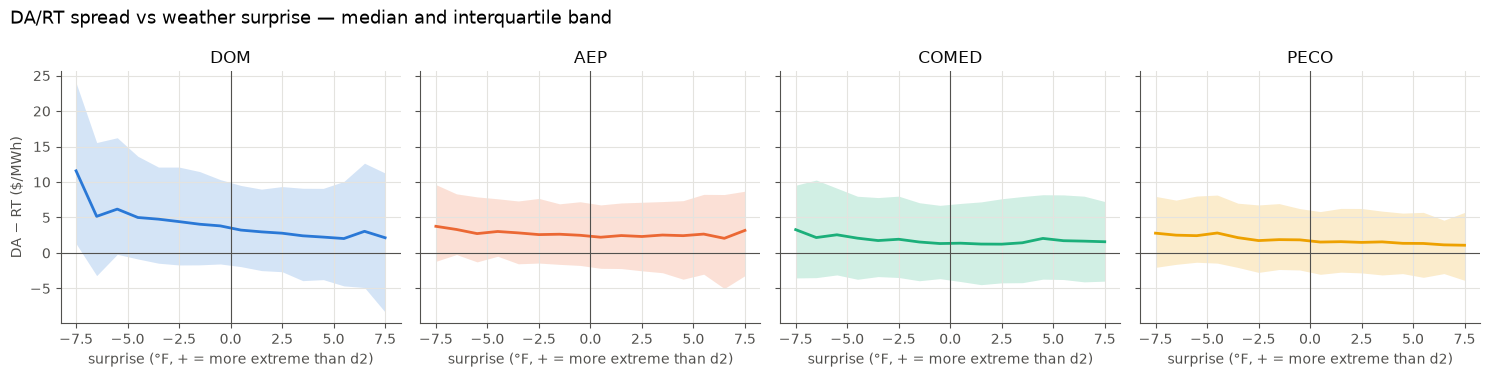

In [21]:
BASE = 65
df['surprise'] = (df['temp_obs_f'] - BASE).abs() - (df['temp_fcst_d2_f'] - BASE).abs()
sbins = np.arange(-8, 8.5, 1)
df['surprise_bin'] = pd.cut(df['surprise'], sbins, labels=sbins[:-1] + 0.5).astype(float)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, zone in zip(axes, ZONES_HERE):
    g = df[df.zone == zone].groupby('surprise_bin')['spread']
    q = g.quantile([0.25, 0.5, 0.75]).unstack()[g.size() >= 50]
    ax.fill_between(q.index, q[0.25], q[0.75], color=ZONE_COLOR[zone], alpha=0.2, linewidth=0)
    ax.plot(q.index, q[0.5], color=ZONE_COLOR[zone])
    ax.axhline(0, color=INK_2, linewidth=0.8)
    ax.axvline(0, color=INK_2, linewidth=0.8)
    ax.set_title(zone)
    ax.set_xlabel('surprise (°F, + = more extreme than d2)')
axes[0].set_ylabel('DA − RT ($/MWh)')
fig.suptitle('DA/RT spread vs weather surprise — median and interquartile band',
             x=0.01, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
spread_corr = (df.dropna(subset=['surprise', 'spread'])
                 .groupby('zone')
                 .apply(lambda z: z['surprise'].corr(z['spread'], method='spearman'), include_groups=False)
                 .loc[ZONES_HERE].rename('spearman(surprise, DA−RT)'))
spread_corr.to_frame().style.format('{:.3f}')

,"spearman(surprise, DA−RT)"
zone,
DOM,-0.083
AEP,-0.030
COMED,-0.018
PECO,-0.055


The surprise effect on the *median* spread is close to zero (|ρ| < 0.04). DA already
clears near RT in typical hours, and a few degrees of forecast miss doesn't move a
typical hour much. The spread's distribution is dominated by tail events (outages,
congestion, scarcity) that a temperature miss alone doesn't predict. If surprise matters,
it will show up in the tails, e.g. cold snaps where d2 underestimated the cold. That's
worth checking with quantile or spike-classification targets, not median correlation.

## Takeaways for modelling

- **Temperature is worth adding.** §7 shows a clear out-of-sample gain over a
  time-of-day + price-level baseline. The response is nonlinear (a hockey stick, steepest
  below about 25°F), so use a spline or hinge transform, not raw temperature or one
  symmetric `|T − 65|` term.
- **DA models:** use `temp_fcst_d2_f`. Compare `obs` vs `d2` in §7: what the leakage-free
  forecast costs against hindsight. `d1` leaks on late-day hours, so don't use it for DA backtests.
- **RT models:** for a day-ahead RT forecast the same d2 feature applies. The weather
  *surprise* doesn't move the median DA/RT spread, so if it's useful at all it'll be for
  predicting RT spikes, not typical-hour spread.
- **Forecast bias** (§4) varies by zone and hour (COMED/PECO d2 runs ~2°F warm overnight).
  Including `hour` in the model absorbs most of it.
- **Regime shifts:** the per-year curve in §6 moves a lot (2022 gas prices, 2026 winter).
  Let the model see the recent price level, as the baseline here does, or a gas price.
- **Gap:** forecast features are missing 2023-12-29 → 2024-01-20. Drop or impute.